# HVSR reference validation

Compute H/V from the three recorded components, independently of the reference curve. Compare the mean curve, its one-standard-deviation bounds, and window-peak statistics against an exported `.hv` file.

The initial profile is verified against the supplied **00P2-2 Geopsy export**. It is not an empirical bandwidth fit: logarithmic width 40% corresponds to `b = pi / log10(1.4)`, with the Konno-Ohmachi kernel truncated at its first zeros. This profile also removes the **mean**, uses a one-sample gap between windows, and searches for **interior** window peaks in a neighbourhood of the mean-curve peak.

This validates one processing configuration, not every Geopsy feature or every recording. Manual window edits, raw/filtered anti-trigger selection, filtering, orientation, and frequency-domain rejection can change results. The reference file does not contain the original window timestamps. Anti-trigger and clipping are disabled here to reproduce the supplied 879-window export; enabling them performs a new selection.

Select the **ciudad-perdida** kernel and run all cells in order. All controls and comments are in English. No reference amplitudes or header statistics are used to generate the computed result.

In [8]:
import hashlib
import importlib
import inspect
import sys
from importlib.metadata import version
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

PROJECT_ROOT = next((p for p in (Path.cwd(), *Path.cwd().parents)
                     if (p / 'utils' / 'hvsr_tools.py').is_file()), None)
if PROJECT_ROOT is None:
    raise FileNotFoundError('Run this notebook from inside the project repository.')
sys.path.insert(0, str(PROJECT_ROOT))
import utils.hvsr_tools as hv
hv = importlib.reload(hv)
if Path(hv.__file__).resolve() != PROJECT_ROOT / 'utils' / 'hvsr_tools.py':
    raise ImportError('A different utils module is loaded. Restart the kernel and run all cells.')
required_fields = {'smoothing_scale', 'smoothing_truncate', 'frequency_grid',
                   'window_gap_samples', 'window_peak_selection'}
if not required_fields.issubset(inspect.signature(hv.HVSRParams).parameters):
    raise ImportError('The HVSR module is outdated. Update it and restart the kernel.')
print('Python:', sys.executable)
print('Module:', hv.__file__)

Python: /home/orincon/miniconda3/envs/ciudad-perdida/bin/python
Module: /home/orincon/ciudad-perdida-hvsr/utils/hvsr_tools.py


## Inputs and processing controls

Change the files and settings below for another station. Use `window_peak_range_hz=(lower, upper)` with `window_peak_selection='mean_band'` for a manual window-peak band. `peak_range_hz` controls the mean-curve peak separately. Missing interior window peaks are excluded from peak statistics, **not** from the mean curve.

`frequency_grid='anchored'` builds the logarithmic sampling relative to 1 Hz rather than forcing the two endpoints. The grid is computed from the parameters, not copied from the reference. `window_gap_samples=1` reproduces the selected-window spacing of this export; use 0 for contiguous windows.

The optional sweep is a sensitivity check, not automatic calibration. It never replaces `params` or the final result. `STRICT_VERIFICATION` fails at the end if any declared tolerance is exceeded.

In [9]:
DATA_DIR = PROJECT_ROOT / 'HVMATLAB'
INPUT_FILES = {c: DATA_DIR / f'00P2-2_WA.WAU40..HH{c}.D.2020.281.sac' for c in 'NEZ'}
REFERENCE_PATH = DATA_DIR / '00P2-2.hv'
OUTPUT_DIR = PROJECT_ROOT / 'main' / '02_analysis_hv' / 'outputs_reference_validation'
OUTPUT_PREFIX = '00P2-2'
RUN_SWEEP = False
STRICT_VERIFICATION = True

SMOOTHING_WIDTH_PCT = 40.0
if not np.isfinite(SMOOTHING_WIDTH_PCT) or SMOOTHING_WIDTH_PCT <= 0:
    raise ValueError('SMOOTHING_WIDTH_PCT must be positive and finite.')

params = hv.HVSRParams(
    window_length_s=32.0,
    overlap_pct=0.0,
    window_selection='grid',
    window_gap_samples=1,
    anti_trigger=False,
    sta_lta_mode='continuous',
    sta_s=2.0, lta_s=25.0,
    sta_lta_min=0.2, sta_lta_max=2.0,
    sta_lta_components=('N', 'E', 'Z'),
    sta_lta_amplitude='abs', sta_lta_on_filtered=False,
    clip_threshold_pct=None,
    filter_corners_hz=(None, None),
    detrend='constant',
    orient_to_degrees_from_north=None,
    taper=True, taper_pct=4.0, taper_pct_per_side=True,
    fft_zero_padding=False,
    smoothing='konno_and_ohmachi',
    smoothing_bandwidth=float(np.pi / np.log10(1 + SMOOTHING_WIDTH_PCT / 100)),
    smoothing_scale='log', smoothing_truncate=True,
    horizontal_combination='squared_average',
    fmin=0.1, fmax=30.0,
    frequency_spacing='log', n_frequencies=500, frequency_grid='anchored',
    peak_range_hz=None, peak_method='max',
    window_peak_selection='mean_band', window_peak_range_hz=None,
    distribution='lognormal', frequency_domain_rejection=False,
)
params.validate()
print('Konno-Ohmachi b:', params.smoothing_bandwidth)

Konno-Ohmachi b: 21.498904293131837


In [10]:
record = hv.load_record(INPUT_FILES)
display(record.meta)
result = hv.run_hvsr(record, params)
summary = result.summary()
display(pd.Series(summary, name='Computed result'))

{'file name(s)': ['/home/orincon/ciudad-perdida-hvsr/HVMATLAB/00P2-2_WA.WAU40..HHN.D.2020.281.sac',
  '/home/orincon/ciudad-perdida-hvsr/HVMATLAB/00P2-2_WA.WAU40..HHE.D.2020.281.sac',
  '/home/orincon/ciudad-perdida-hvsr/HVMATLAB/00P2-2_WA.WAU40..HHZ.D.2020.281.sac'],
 'deployed degrees from north': 0.0,
 'current degrees from north': 0.0,
 'station': '00P2-2',
 'starttime': '2020-10-07T08:18:39.000000Z',
 'sampling_rate_hz': 100.0,
 'duration_s': 28160.99}

windows 879/879  |  f0 = 9.462 Hz, A0 = 4.84  |  f0 windows = 8.772 Hz  [0.3 s]


n_grid_windows                                                   879
n_windows_time_selection                                         879
n_windows                                                        879
valid_fraction                                                   1.0
f0_mean_curve_hz                                            9.462062
A0_mean_curve                                               4.841838
f0_windows_hz                                                8.77168
f0_windows_std                                              0.119517
f0_windows_low_hz                                            7.78354
f0_windows_high_hz                                          9.885267
A0_windows                                                  5.254559
n_windows_f0                                                     870
A0_at_f0_windows                                            4.730771
window_peak_range_hz        (6.6559687556767875, 13.451176585266849)
fdr_iterations                    

## Independent reference comparison

`f0 from average` is the mean-curve maximum. `f0 from windows` is the geometric mean of valid interior window-peak frequencies in the selected band. Geopsy's `f0 amplitude` is the **mean curve evaluated at the window-peak frequency**, not the mean of individual peak amplitudes. These quantities are reported separately.

Compare all 500 curve values and both statistical bounds, not just the peak. Text exports round frequencies and amplitudes, so tolerances allow small numerical/rounding differences. The default maximum pointwise error allowed is **0.01%**; scalar peak statistics use relative tolerance **0.001%**. Window counts must match exactly.

n_windows             879.00000
f0_hz                   9.46206
n_windows_f0          870.00000
f0_windows_hz           8.77168
f0_windows_low_hz       7.78354
f0_windows_high_hz      9.88527
A0_at_f0_windows        4.73077
Name: Reference header, dtype: float64

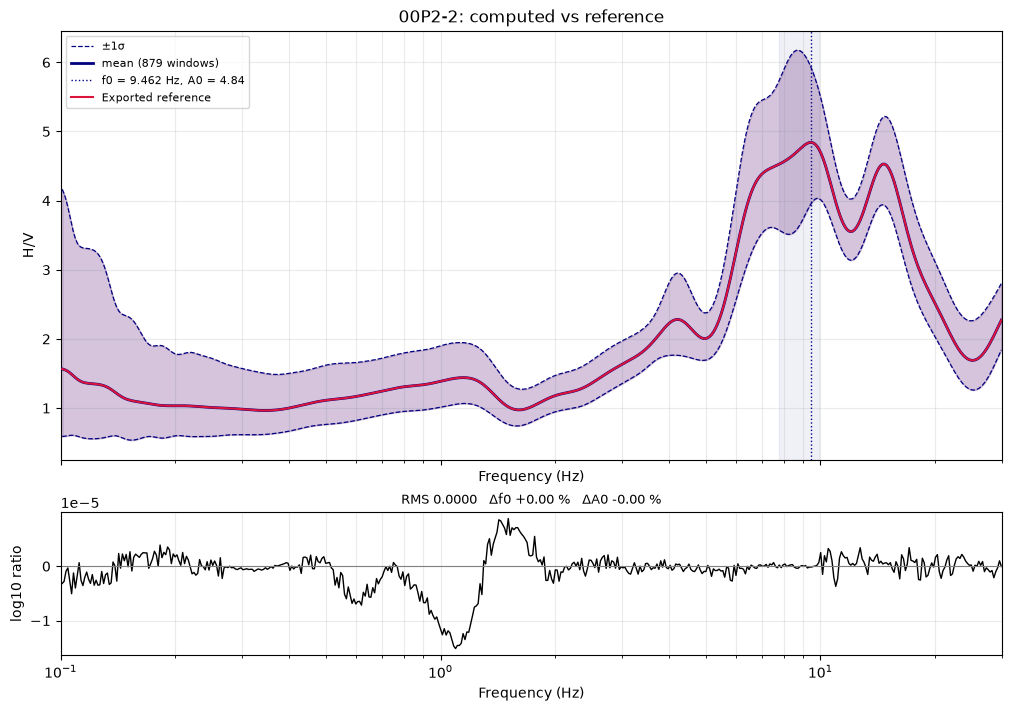

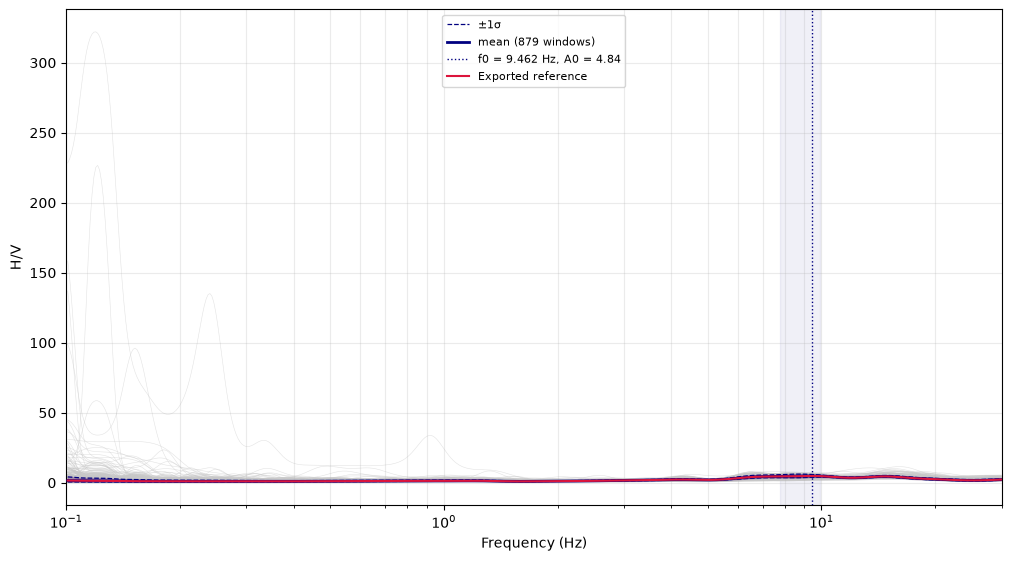

In [11]:
reference = hv.read_reference_curve(REFERENCE_PATH, label='Exported reference')
metrics = hv.compare_curves(result, reference)
display(pd.Series(reference.metadata, name='Reference header'))
comparison_figure = hv.plot_comparison(result, reference, title=f'{OUTPUT_PREFIX}: computed vs reference')
plt.show()
window_axes = hv.plot_hvsr(result, show_windows=True, reference=reference)
plt.show()

In [12]:
SCALAR_RTOL = 1e-5
MAX_CURVE_ERROR_PCT = 0.01
rows = []
scalar_pairs = [
    ('n_windows', summary['n_windows'], reference.metadata.get('n_windows'), 0),
    ('n_windows_f0', summary['n_windows_f0'], reference.metadata.get('n_windows_f0'), 0),
    ('f0_mean_curve_hz', summary['f0_mean_curve_hz'], reference.metadata.get('f0_hz'), SCALAR_RTOL),
    ('A0_mean_curve', summary['A0_mean_curve'], reference.peak()[1], SCALAR_RTOL),
    ('f0_windows_hz', summary['f0_windows_hz'], reference.metadata.get('f0_windows_hz'), SCALAR_RTOL),
    ('f0_windows_low_hz', summary['f0_windows_low_hz'], reference.metadata.get('f0_windows_low_hz'), SCALAR_RTOL),
    ('f0_windows_high_hz', summary['f0_windows_high_hz'], reference.metadata.get('f0_windows_high_hz'), SCALAR_RTOL),
    ('A0_at_f0_windows', summary['A0_at_f0_windows'], reference.metadata.get('A0_at_f0_windows'), SCALAR_RTOL),
]
for name, value, expected, tolerance in scalar_pairs:
    expected = np.nan if expected is None else expected
    error = abs(value / expected - 1) if expected != 0 else abs(value - expected)
    rows.append(dict(check=name, computed=value, reference=expected,
                     error=error, tolerance=tolerance,
                     passed=bool(np.isfinite(error) and error <= tolerance)))
for name in ('max_abs_curve_pct', 'lower_max_abs_pct', 'upper_max_abs_pct'):
    value = metrics.get(name, np.nan)
    rows.append(dict(check=name, computed=value, reference=0.0, error=value,
                     tolerance=MAX_CURVE_ERROR_PCT,
                     passed=bool(np.isfinite(value) and value <= MAX_CURVE_ERROR_PCT)))
same_size = result.frequency.shape == reference.frequency.shape
grid_error = float(np.max(np.abs(result.frequency / reference.frequency - 1))) if same_size else np.inf
rows.append(dict(check='frequency_grid_relative_error', computed=grid_error, reference=0,
                 error=grid_error, tolerance=5e-6, passed=bool(grid_error <= 5e-6)))
verification = pd.DataFrame(rows)
verified = bool(verification['passed'].all())
display(verification)
display(pd.Series(metrics, name='Curve and peak comparison'))
print('Reference verification:', 'PASS' if verified else 'FAIL')

,check,computed,reference,error,tolerance,passed
0,n_windows,879.000000,879.00000,0.000000e+00,0.000000,True
1,n_windows_f0,870.000000,870.00000,0.000000e+00,0.000000,True
2,f0_mean_curve_hz,9.462062,9.46206,1.766716e-07,0.000010,True
3,A0_mean_curve,4.841838,4.84184,3.645728e-07,0.000010,True
4,f0_windows_hz,8.771680,8.77168,2.100331e-08,0.000010,True
5,f0_windows_low_hz,7.783540,7.78354,5.631809e-08,0.000010,True
6,f0_windows_high_hz,9.885267,9.88527,3.032430e-07,0.000010,True
7,A0_at_f0_windows,4.730771,4.73077,2.378316e-07,0.000010,True
8,max_abs_curve_pct,0.003487,0.00000,3.486548e-03,0.010000,True
9,lower_max_abs_pct,0.002912,0.00000,2.912172e-03,0.010000,True


rms_log10                 3.531777e-06
bias_log10               -7.080580e-07
max_abs_log10             1.514215e-05
max_abs_curve_pct         3.486548e-03
f0_hz                     9.462062e+00
f0_ref_hz                 9.462060e+00
df0_pct                   1.766716e-05
A0                        4.841838e+00
A0_ref                    4.841840e+00
dA0_pct                  -3.645728e-05
f0_windows_hz             8.771680e+00
f0_windows_ref_hz         8.771680e+00
n_windows                 8.790000e+02
n_windows_ref             8.790000e+02
n_windows_f0              8.700000e+02
n_windows_f0_ref          8.700000e+02
f0_windows_low_hz         7.783540e+00
f0_windows_low_hz_ref     7.783540e+00
f0_windows_high_hz        9.885267e+00
f0_windows_high_hz_ref    9.885270e+00
A0_at_f0_windows          4.730771e+00
A0_at_f0_windows_ref      4.730770e+00
lower_rms_log10           3.089901e-06
lower_max_abs_pct         2.912172e-03
upper_rms_log10           5.144079e-06
upper_max_abs_pct        

Reference verification: PASS


In [13]:
SWEEP_GRID = {
    'smoothing_bandwidth': [20.0, params.smoothing_bandwidth, 22.0, 40.0],
    'smoothing_scale': ['linear', 'log'],
    'smoothing_truncate': [False, True],
}
if RUN_SWEEP:
    sweep = hv.parameter_sweep(record, params, SWEEP_GRID, reference=reference)
    display(sweep)
    if 'error' in sweep and sweep['error'].notna().any():
        raise RuntimeError('Some sweep combinations failed; inspect the error column before using the results.')

## Save reproducible outputs and enforce the checks

Save the computed curve, per-window timestamps and peaks, parameters, comparison metrics, input/reference SHA-256 hashes, package versions, plots and the verification table. Outputs go to a separate folder; the original reference is never overwritten.

SESAME is a quality assessment, not a test of software equivalence. Run `result.sesame()` separately if needed. To experiment with intentionally different processing, set `STRICT_VERIFICATION=False`; a failed comparison is still shown and saved as a failure.

In [14]:
def sha256(path):
    with Path(path).open('rb') as stream:
        return hashlib.file_digest(stream, 'sha256').hexdigest()

provenance = {
    'python': sys.version,
    'packages': {name: version(name) for name in ('hvsrpy', 'obspy', 'numpy', 'scipy', 'pandas')},
    'module_sha256': sha256(hv.__file__),
    'inputs': {c: {'path': str(p), 'sha256': sha256(p)} for c, p in INPUT_FILES.items()},
    'reference': {'path': str(REFERENCE_PATH), 'sha256': sha256(REFERENCE_PATH)},
}
paths = hv.save_outputs(result, OUTPUT_DIR, prefix=OUTPUT_PREFIX,
                        extra={'comparison': metrics, 'verification_passed': verified,
                               'verification': verification.to_dict(orient='records'),
                               'provenance': provenance})
verification.to_csv(OUTPUT_DIR / f'{OUTPUT_PREFIX}_verification.csv', index=False)
comparison_figure.savefig(OUTPUT_DIR / f'{OUTPUT_PREFIX}_comparison.png', dpi=160)
window_axes.figure.savefig(OUTPUT_DIR / f'{OUTPUT_PREFIX}_windows.png', dpi=160)
if RUN_SWEEP:
    sweep.to_csv(OUTPUT_DIR / f'{OUTPUT_PREFIX}_sensitivity.csv', index=False)
display(paths)
if STRICT_VERIFICATION and not verified:
    failed = verification.loc[~verification['passed'], 'check'].tolist()
    raise AssertionError(f'Reference verification failed: {failed}. Details are saved in {OUTPUT_DIR}.')

{'curve': PosixPath('/home/orincon/ciudad-perdida-hvsr/main/02_analysis_hv/outputs_reference_validation/00P2-2.hv'),
 'windows': PosixPath('/home/orincon/ciudad-perdida-hvsr/main/02_analysis_hv/outputs_reference_validation/00P2-2_windows.csv'),
 'summary': PosixPath('/home/orincon/ciudad-perdida-hvsr/main/02_analysis_hv/outputs_reference_validation/00P2-2_summary.json')}